In [2]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt

### Step 1. Upload yaml file data

In [3]:
with open('data2/books.yaml', 'r', encoding='utf-8') as file:
    data = yaml.safe_load(file)

In [4]:
books_df = pd.DataFrame(data)
print(books_df)

       :id                              :title                        :author  \
0    21326                      Behold the Man  Trenton Sipes, Clint Hauck VM   
1    21546                     The Deer Hunter              Norris Gusikowski   
2    21130                              Snatch            Rev. Lura Jaskolski   
3    21287                   Dial M for Murder                Miss Elmo Walsh   
4    21237                        The Departed                Mario Aufderhar   
..     ...                                 ...                            ...   
736  21002  Commandos: Beyond the Call of Duty                   Noma Kris VM   
737  21045                     Pokémon FireRed              Rep. Albert Stamm   
738  20972                  The Maltese Falcon                    Coy Hegmann   
739  20935                            Oldeuboi               Virgilio Bernier   
740  21241                            Crysis 2           Mrs. Dario Jaskolski   

                :genre     

### Step 2. Data preparation for yaml file

#### Step 2.1. Columns cleaning

In [5]:
books_df.columns = books_df.columns.str.replace(":", "", regex=False)

In [6]:
books_df.head()

,id,title,author,genre,publisher,year
0,21326,Behold the Man,"Trenton Sipes, Clint Hauck VM",Reference book,Bowes & Bowes,1979
1,21546,The Deer Hunter,Norris Gusikowski,Reference book,Koren Publishers Jerusalem,1993
2,21130,Snatch,Rev. Lura Jaskolski,Fable,Left Book Club,2000
3,21287,Dial M for Murder,Miss Elmo Walsh,Textbook,Libertas Academica,1977
4,21237,The Departed,Mario Aufderhar,Folklore,BBC Books,2015


#### Step 2.2. Type conversion in the <i>title</i> and <i>author</i> columns

In [7]:
books_df["title"] = books_df["title"].astype("string")
books_df["author"] = books_df["author"].astype("string")

#### Step 2.3. Cleaning and conversion <i>year</i> column

In [8]:
mask = pd.to_numeric(books_df["year"], errors="coerce").isna() & books_df["year"].notna()
books_df.loc[mask, "year"].unique()

array([' ', '-', '', '\t'], dtype=object)

In [9]:
books_df.loc[mask, ["title", "year"]]

,title,year
28,Kirby's Epic Yarn,
496,Titanic: Music from the Motion Picture,-
515,Before Sunrise,
570,Unweaving the Rainbow,\t


In [10]:
books_df["year"] = books_df["year"].astype("string").str.strip()

In [11]:
books_df["year"] = pd.to_numeric(books_df["year"], errors="coerce").astype("Int16")

#### Step 2.4. Type conversion in the <i>publisher</i> column

In [12]:
books_df["publisher"].nunique()

247

In [13]:
books_df["publisher"].nunique(dropna=False)

248

In [14]:
books_df["publisher"].value_counts(dropna=False)

publisher
Godwit Press                  8
Athabasca University Press    8
Applewood Books               8
Carcanet Press                7
Pecan Grove Press             7
                             ..
New Directions Publishing     1
J. M. Dent                    1
Caister Academic Press        1
Kodansha                      1
Adis International            1
Name: count, Length: 248, dtype: int64

In [15]:
books_df["publisher"] = (
    books_df["publisher"]
    .astype("string")
    .str.strip()
    .replace(["", "NULL", "-"], pd.NA)
    .astype("category")
)

In [16]:
books_df["publisher"].dtype

CategoricalDtype(categories=['Ace Books', 'Addison-Wesley', 'Adis International',
                  'Airiti Press', 'Allen Ltd', 'Andrews McMeel Publishing',
                  'André Deutsch', 'Anova Books', 'Anvil Press Poetry',
                  'Applewood Books',
                  ...
                  'Verso Books', 'Viking Press', 'Vintage Books',
                  'Vintage Books at Random House', 'Virago Press',
                  'Virgin Publishing', 'Voyager Books', 'Zed Books',
                  'Ziff Davis Media', 'Zondervan'],
, ordered=False, categories_dtype=string)

In [17]:
books_df["publisher"].nunique(dropna=False)

243

#### Step 2.5. Type conversion in the <i>genre</i> column

In [18]:
books_df["genre"].nunique(dropna=False)

30

In [19]:
books_df["genre"].value_counts(dropna=False).tail(30)

genre
Suspense/Thriller          36
Essay                      35
Comic/Graphic Novel        31
Fable                      29
Textbook                   29
Reference book             28
Metafiction                28
Realistic fiction          27
Mystery                    27
Fantasy                    27
Legend                     27
Tall tale                  27
Horror                     26
Western                    25
Crime/Detective            25
Fairy tale                 24
Fiction in verse           24
Fiction narrative          24
Humor                      23
Narrative nonfiction       23
Short story                23
Biography/Autobiography    22
Mythopoeia                 22
Mythology                  20
Fanfiction                 20
Historical fiction         20
Science fiction            19
Classic                    18
Speech                     17
Folklore                   15
Name: count, dtype: int64

In [20]:
books_df["genre"] = books_df["genre"].astype("category")

In [21]:
books_df["genre"].dtype

CategoricalDtype(categories=['Biography/Autobiography', 'Classic', 'Comic/Graphic Novel',
                  'Crime/Detective', 'Essay', 'Fable', 'Fairy tale',
                  'Fanfiction', 'Fantasy', 'Fiction in verse',
                  'Fiction narrative', 'Folklore', 'Historical fiction',
                  'Horror', 'Humor', 'Legend', 'Metafiction', 'Mystery',
                  'Mythology', 'Mythopoeia', 'Narrative nonfiction',
                  'Realistic fiction', 'Reference book', 'Science fiction',
                  'Short story', 'Speech', 'Suspense/Thriller', 'Tall tale',
                  'Textbook', 'Western'],
, ordered=False, categories_dtype=str)

#### Step 2.5. Checking data 

In [22]:
books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 741 entries, 0 to 740
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         741 non-null    int64   
 1   title      741 non-null    string  
 2   author     741 non-null    string  
 3   genre      741 non-null    category
 4   publisher  724 non-null    category
 5   year       735 non-null    Int16   
dtypes: Int16(1), category(2), int64(1), string(2)
memory usage: 57.9 KB


### Step 3. Upload parquet file

In [26]:
orders_df = pd.read_parquet("data2/orders.parquet", engine="fastparquet")

In [27]:
orders_df.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,75198,55590,21465,1,73.5$,"08:47:31 P.M.,10/07/24",NULL
1,82023,53482,21374,1,$25.00,2024-09-11T05:27:49,NULL
2,81439,55123,21408,1,USD22.50,"2024-08-06,06:53",
3,80259,54387,21013,1,42.5$,03/18/25;09:32:41 AM,
4,80176,54916,21437,1,$ 62.5,"04:55:14 pm,09/24/24",NULL


In [28]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9850 entries, 0 to 9849
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          9850 non-null   int64 
 1   user_id     9850 non-null   int64 
 2   book_id     9850 non-null   int64 
 3   quantity    9850 non-null   int32 
 4   unit_price  9850 non-null   object
 5   timestamp   9850 non-null   object
 6   shipping    7467 non-null   object
dtypes: int32(1), int64(3), object(3)
memory usage: 500.3+ KB


### Step 4. Data preparation for <i>parquet</i> file

#### Step 4.1. Type conversion in the <i>timestamp</i> column

In [29]:
clean_ts = (
    orders_df["timestamp"]
    .astype("string")
    .str.strip()
    .str.replace("A.M.", "AM", regex=False)
    .str.replace("P.M.", "PM", regex=False)
    .str.replace(";", " ", regex=False)
    .str.replace(",", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

orders_df["timestamp_parsed"] = pd.to_datetime(
    clean_ts,
    format="mixed",
    errors="coerce",
    dayfirst=True
)

In [30]:
orders_df["date"] = orders_df["timestamp_parsed"].dt.normalize()

In [31]:
bad_mask = orders_df["timestamp_parsed"].isna() & orders_df["timestamp"].notna()
orders_df.loc[bad_mask, "timestamp"].unique()

array([], dtype=object)

In [32]:
orders_df.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,timestamp_parsed,date
0,75198,55590,21465,1,73.5$,"08:47:31 P.M.,10/07/24",NULL,2024-07-10 20:47:31,2024-07-10
1,82023,53482,21374,1,$25.00,2024-09-11T05:27:49,NULL,2024-11-09 05:27:49,2024-11-09
2,81439,55123,21408,1,USD22.50,"2024-08-06,06:53",,2024-06-08 06:53:00,2024-06-08
3,80259,54387,21013,1,42.5$,03/18/25;09:32:41 AM,,2025-03-18 09:32:41,2025-03-18
4,80176,54916,21437,1,$ 62.5,"04:55:14 pm,09/24/24",NULL,2024-09-24 16:55:14,2024-09-24


#### Step 4.2. Type conversion in the <i>unit price</i> column

In [33]:
price_raw = (
    orders_df["unit_price"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", "", regex=True)
)

orders_df["unit_price_currency"] = (
    price_raw
    .str.extract(r"(USD|EUR|\$|€)", expand=False)
    .replace({"$": "USD", "€": "EUR"})
)

amount_str = (
    price_raw
    .str.replace(r"^(\d+)(\$|€)(\d+)¢$", r"\1.\3", regex=True)
    .str.replace(r"^(USD|EUR|\$|€)(\d+)¢(\d+)$", r"\2.\3", regex=True)
    .str.replace(r"USD|EUR|\$|€", "", regex=True)
    .str.replace("¢", ".", regex=False)
    .str.replace(",", ".", regex=False)
    .str.replace(r"[^\d.]", "", regex=True)
)

orders_df["unit_price_value"] = pd.to_numeric(amount_str, errors="coerce")

In [34]:
orders_df[["unit_price", "unit_price_currency", "unit_price_value"]].head(20)

,unit_price,unit_price_currency,unit_price_value
0,73.5$,USD,73.5
1,$25.00,USD,25.0
2,USD22.50,USD,22.5
3,42.5$,USD,42.5
4,$ 62.5,USD,62.5
5,$ 73.0,USD,73.0
6,$ 41.75,USD,41.75
7,46.0 $,USD,46.0
8,22.USD,USD,22.0
9,57.00EUR,EUR,57.0


In [35]:
orders_df[["unit_price", "unit_price_currency", "unit_price_value"]].tail(20)

,unit_price,unit_price_currency,unit_price_value
9830,58.0 €,EUR,58.0
9831,$54.50,USD,54.5
9832,€ 36,EUR,36.0
9833,$ 53.75,USD,53.75
9834,37.5 $,USD,37.5
9835,60.5 $,USD,60.5
9836,39.5$,USD,39.5
9837,$ 49.25,USD,49.25
9838,EUR14.,EUR,14.0
9839,51.75 EUR,EUR,51.75


In [36]:
bad_mask = orders_df["unit_price_value"].isna() | orders_df["unit_price_currency"].isna()
orders_df.loc[bad_mask, "unit_price"].drop_duplicates()

Series([], Name: unit_price, dtype: object)

#### Step 4.3. Currency conversion in the <i>unit price</i> column

In [37]:
mask = (orders_df["unit_price_currency"] == "EUR")

orders_df.loc[mask, "unit_price_value"] = (
    orders_df.loc[mask, "unit_price_value"] * 1.2
).round(2)

orders_df.loc[mask, "unit_price_currency"] = "USD"

In [38]:
orders_df["unit_price_currency"].value_counts(dropna=False)

unit_price_currency
USD    9850
Name: count, dtype: int64[pyarrow]

In [39]:
orders_df[["unit_price_currency", "unit_price_value"]].tail(20)

,unit_price_currency,unit_price_value
9830,USD,69.6
9831,USD,54.5
9832,USD,43.2
9833,USD,53.75
9834,USD,37.5
9835,USD,60.5
9836,USD,39.5
9837,USD,49.25
9838,USD,16.8
9839,USD,62.1


#### Step 4.4. Adding a <i>paid price</i> column

In [40]:
orders_df["paid_price"] = orders_df["quantity"] * orders_df["unit_price_value"]

#### Step 4.5. Checking data

In [42]:
orders_df = orders_df.drop(columns=["timestamp", "timestamp_parsed", "unit_price"])

In [43]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9850 entries, 0 to 9849
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   9850 non-null   int64         
 1   user_id              9850 non-null   int64         
 2   book_id              9850 non-null   int64         
 3   quantity             9850 non-null   int32         
 4   shipping             7467 non-null   object        
 5   date                 9850 non-null   datetime64[us]
 6   unit_price_currency  9850 non-null   string        
 7   unit_price_value     9850 non-null   Float64       
 8   paid_price           9850 non-null   Float64       
dtypes: Float64(2), datetime64[us](1), int32(1), int64(3), object(1), string(1)
memory usage: 702.3+ KB


In [44]:
orders_df.head()

,id,user_id,book_id,quantity,shipping,date,unit_price_currency,unit_price_value,paid_price
0,75198,55590,21465,1,NULL,2024-07-10,USD,73.5,73.5
1,82023,53482,21374,1,NULL,2024-11-09,USD,25.0,25.0
2,81439,55123,21408,1,,2024-06-08,USD,22.5,22.5
3,80259,54387,21013,1,,2025-03-18,USD,42.5,42.5
4,80176,54916,21437,1,NULL,2024-09-24,USD,62.5,62.5


### Step 5. Upload csv file

In [45]:
users_df = pd.read_csv("data2/users.csv")

In [46]:
users_df.head(5)

,id,name,address,phone,email
0,53386,Jacqulyn Mante,"566 Emelina Turnpike, Lashundaside, NE 78034-5281",962.715.8009,leonardo.leannon@wintheiser-lueilwitz.example
1,54635,Devon Leannon III,,(537) 133-9394,jon_torp@bayer.example
2,55435,Shiloh Keebler,"425 Wesley Hills, Nathanialburgh, MS 08004",474.242.3397,murray_mcclure@pfeffer.example
3,53627,Luke Rolfson,"Suite 556 20616 Little Union, Connieside, VT 3...",927.381.8818,murray.shanahan@heathcote.example
4,55650,Prince Braun,"981 Howell Spring, New Sheldon, LA 62246-1232",686-186-1306,anitra@pollich-kris.example


In [47]:
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       2810 non-null   int64
 1   name     2810 non-null   str  
 2   address  2713 non-null   str  
 3   phone    2810 non-null   str  
 4   email    2810 non-null   str  
dtypes: int64(1), str(4)
memory usage: 385.5 KB


### Step 6. Data preparation for csv file

#### Step 6.1. Formatting <i>phone</i> column

In [48]:
phones = users_df["phone"].astype("string").str.replace(r"\D", "", regex=True)

users_df["phone_clean"] = phones
users_df["phone_formatted"] = phones.str.replace(
    r"^(\d{3})(\d{3})(\d{4})$",
    r"(\1) \2-\3",
    regex=True
)

In [49]:
# To check "broken" phones
phones = users_df["phone"].astype("string").str.replace(r"\D", "", regex=True)
bad_mask = phones.str.len() != 10
users_df.loc[bad_mask, "phone"].drop_duplicates()

Series([], Name: phone, dtype: str)

#### Step 6.2. Checking data

In [57]:
users_df.head()

,id,name,address,phone,email
0,53386,Jacqulyn Mante,"566 Emelina Turnpike, Lashundaside, NE 78034-5281",(962) 715-8009,leonardo.leannon@wintheiser-lueilwitz.example
1,54635,Devon Leannon III,,(537) 133-9394,jon_torp@bayer.example
2,55435,Shiloh Keebler,"425 Wesley Hills, Nathanialburgh, MS 08004",(474) 242-3397,murray_mcclure@pfeffer.example
3,53627,Luke Rolfson,"Suite 556 20616 Little Union, Connieside, VT 3...",(927) 381-8818,murray.shanahan@heathcote.example
4,55650,Prince Braun,"981 Howell Spring, New Sheldon, LA 62246-1232",(686) 186-1306,anitra@pollich-kris.example


In [56]:
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       2810 non-null   int64 
 1   name     2810 non-null   str   
 2   address  2713 non-null   str   
 3   phone    2810 non-null   string
 4   email    2810 non-null   str   
dtypes: int64(1), str(3), string(1)
memory usage: 390.0 KB


In [55]:
users_df["phone"] = users_df["phone_formatted"]
users_df = users_df.drop(columns=["phone_clean", "phone_formatted"])

### Step 7. Task 1 - top 5 days by revenue

In [58]:
daily_revenue_df = (
    orders_df
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "daily_revenue"})
    .sort_values("daily_revenue", ascending=False)
)

top_5_days = daily_revenue_df.head(5)
print(top_5_days)

          date  daily_revenue
300 2024-11-15        3677.17
306 2024-11-21        3590.09
340 2024-12-25        3572.11
366 2025-01-20        3561.51
329 2024-12-14        3514.39


### Step 8. Task 2 - unique users number

In [59]:
df = users_df.copy()

for col in ["name", "address", "phone"]:
    df[col] = df[col].astype("string").str.strip().str.lower()

for col in ["name", "address", "phone"]:
    df[col] = df[col].replace(["", "nan", "none"], pd.NA)

parent = list(range(len(df)))

In [60]:
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

In [61]:
doubles = [
    ["name", "address"],
    ["name", "phone"],
    ["address", "phone"],
]

In [62]:
for cols in doubles:
    temp = df.reset_index().dropna(subset=cols)
    grouped = temp.groupby(cols)["index"].apply(list)

    for ids in grouped:
        first = ids[0]
        for other in ids[1:]:
            union(first, other)

real_unique_users = len({find(i) for i in range(len(df))})
print(real_unique_users)

2663


### Step 9. Task 3 - unique sets of authors

In [63]:
author_sets = (
    books_df["author"]
    .astype("string")
    .str.lower()
    .str.split(",")
    .apply(lambda authors: tuple(sorted(a.strip() for a in authors if a.strip())))
)

unique_author_sets_count = author_sets.nunique()
print(unique_author_sets_count)

293


### Step 10. Task 4 - the most popular author

In [64]:
books_tmp = books_df.copy()

books_tmp["author_set"] = (
    books_tmp["author"]
    .astype("string")
    .str.lower()
    .str.split(",")
    .apply(lambda authors: tuple(sorted(a.strip() for a in authors if a.strip())))
)

author_set_sales = (
    orders_df
    .merge(books_tmp[["id", "author_set"]], left_on="book_id", right_on="id", how="left")
    .groupby("author_set", as_index=False)["quantity"]
    .sum()
    .rename(columns={"quantity": "sold_book_count"})
    .sort_values("sold_book_count", ascending=False)
)

print(author_set_sales.head(1))

                                            author_set  sold_book_count
133  (hershel treutel, miss modesto denesik, sen. t...              163


### Step 11. Task 5 - top customer

In [65]:
users_df["customer_group"] = [find(i) for i in range(len(df))]

In [66]:
user_group_map = users_df[["id", "customer_group"]]

customer_spending = (
    orders_df
    .merge(user_group_map, left_on="user_id", right_on="id", how="left")
    .groupby("customer_group", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "total_spending"})
    .sort_values("total_spending", ascending=False)
)

top_group = customer_spending.iloc[0]["customer_group"]
top_total_spending = customer_spending.iloc[0]["total_spending"]

top_customer_user_ids = users_df.loc[
    users_df["customer_group"] == top_group, "id"
].tolist()

print("Top customer group:", top_group)
print("Total spending:", top_total_spending)
print("All related user_id values:", top_customer_user_ids)

Top customer group: 305.0
Total spending: 1312.84
All related user_id values: [53583, 55058, 55420]


In [67]:
top_customer_records = users_df.loc[
    users_df["customer_group"] == top_group,
    ["id", "name", "address", "email", "phone"]
]

print(top_customer_records)

         id               name  \
305   53583  Catina Altenwerth   
1306  55058     Tilda Hartmann   
1752  55420  Catina Altenwerth   

                                               address  \
305   3740 Lemke Creek, Konopelskihaven, ME 71939-4348   
1306  3740 Lemke Creek, Konopelskihaven, ME 71939-4348   
1752    Apt. 624 9824 Effie Key, Port Virgie, VT 12128   

                                    email           phone  
305   lilia_mueller@sanford-franecki.test  (100) 233-1733  
1306  lilia_mueller@sanford-franecki.test  (100) 233-1733  
1752  lilia_mueller@sanford-franecki.test  (100) 233-1733  


### Step 12. Task 6 - line chart of daily revenue

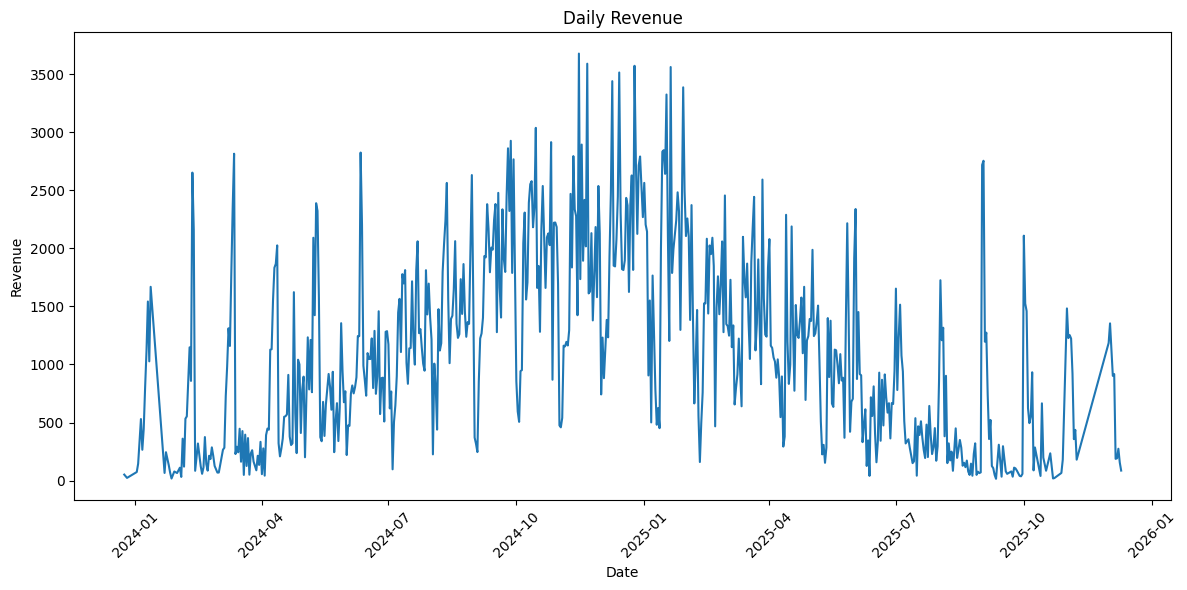

In [68]:
daily_revenue_df = (
    orders_df
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "daily_revenue"})
    .sort_values("date")
)

plt.figure(figsize=(12, 6))
plt.plot(daily_revenue_df["date"], daily_revenue_df["daily_revenue"])
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
daily_revenue_df.to_csv("daily_revenue_data_2.csv", index=False)